# Cleaning/Imports

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
from plotnine import *
import os
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
from patsy import dmatrices
from stargazer.stargazer import Stargazer
from statsmodels.graphics.factorplots import interaction_plot

os.getcwd()

#Pandas Options
pd.set_option('display.float_format', '{:,.0f}'.format)
warnings.filterwarnings("ignore")

In [3]:
rawdata = pd.read_csv('FraudData.csv')
rawdata = rawdata.drop(["Type de plainte recue",
                        "Categories thematiques sur la fraude et la cybercriminalite",
                        "Genre",
                        "Methode de sollicitation",
                        "Type de plainte",
                        "Langue de correspondance",
                        "Province/Etat",
                        "Pays"],axis=1)

fraudData = rawdata.rename(columns={"Numero d'identification / Number ID": "Number ID", 
                                    "Date Received / Date recue":"Date Received",
                                    "Victim Age Range / Tranche d'age des victimes":  "Age",
                                    "Number of Victims / Nombre de victimes":"Number of Victims",
                                    "Dollar Loss /pertes financieres":"Dollar Loss",
                                    "Fraud and Cybercrime Thematic Categories":"Category",
                                    "Language of Correspondence":"Language",
                                    "Solicitation Method":"SolicitMethod"})

#Clean Values
# Remove leading apostrophes
fraudData.loc[:, "Age"] = fraudData["Age"].str.replace("^'", "", regex=True)
fraudData.loc[fraudData["Age"] == "Not Available / non disponible", "Age"] = pd.NA
fraudData.loc[fraudData["Age"] == "Deceased / Décédé", "Age"] = pd.NA
fraudData.loc[fraudData["Age"] == "Business / Entreprise", "Age"] = pd.NA
fraudData.loc[fraudData["Gender"] == "Not Available", "Gender"] = pd.NA
fraudData.loc[fraudData["Gender"] == "Other", "Gender"] = pd.NA
fraudData.loc[fraudData["Gender"] == "Unknown", "Gender"] = pd.NA
fraudData.loc[fraudData["Gender"] == "Prefer not to say", "Gender"] = pd.NA
fraudData.loc[fraudData["Language"] == "Not Available", "Language"] = pd.NA
fraudData.loc[fraudData["Province/State"] == "Not Available", "Province/State"] = pd.NA
fraudData.loc[fraudData["SolicitMethod"] == "Other/unknown", "SolicitMethod"] = pd.NA
fraudData.loc[fraudData["SolicitMethod"] == "Not Available", "SolicitMethod"] = pd.NA
fraudData.loc[fraudData["Category"] == "Unknown", "Category"] = pd.NA
fraudData.loc[fraudData["Category"] == "Incomplete", "Category"] = pd.NA


# Have to remove the $ and comma to get an actual integer
fraudData['Dollar Loss'] = (fraudData['Dollar Loss']
                            .str.replace('$', '', regex=False)
                            .str.replace(',', '', regex=False)
                            .astype(float)
                            .astype(int))
#Convert Date/Time to Pandas + sort
fraudData["Date Received"] = pd.to_datetime(fraudData["Date Received"])
fraudData = fraudData.sort_values("Date Received")
fraudData['Year'] = pd.DatetimeIndex(fraudData['Date Received']).year
#
fraudData.loc[fraudData["Complaint Type"] == "Attempt", "Dollar Loss"] = pd.NA


#Make two new Dataframes - One that is for individuals who were
#scammed and one for those who put in a complaint
victimData  = fraudData[fraudData["Complaint Type"]== "Victim"]
attemptData = fraudData[fraudData["Complaint Type"]== "Attempt"]

fraudData.head()

,Number ID,Date Received,Complaint Received Type,Country,Province/State,Category,SolicitMethod,Gender,Language,Age,Complaint Type,Number of Victims,Dollar Loss,Year
0,1,2021-01-02,CAFC Website,Canada,Nova Scotia,Phishing,Text message,Female,English,30 - 39,Attempt,0,NaN,2021
51,52,2021-01-02,CAFC Website,Not Specified,Not Specified,Phishing,Text message,<NA>,<NA>,<NA>,Attempt,0,NaN,2021
50,51,2021-01-02,CAFC Website,Canada,Alberta,Identity Fraud,<NA>,Male,English,20 - 29,Victim,1,0,2021
49,50,2021-01-02,CAFC Website,Canada,Quebec,<NA>,Text message,Male,French,40 - 49,Attempt,0,NaN,2021
48,49,2021-01-02,CAFC Website,Canada,Saskatchewan,Merchandise,<NA>,Male,<NA>,60 - 69,Victim,1,222,2021


# Analysis

In [4]:
# We will be combining the lowest 3 sets
victimData["Age"].value_counts()

Age
30 - 39    31075
20 - 29    26298
40 - 49    26064
60 - 69    22214
50 - 59    21805
70 - 79    12360
10 - 19     8791
80 - 89     3979
90 - 99      500
1 - 9        111
100 +         40
Name: count, dtype: int64

In [5]:
# Lists
#Combination Data

highEffortList = [
    "Romance", 
    "Investments", 
    "Foreign Money Offer", 
    "Timeshare", 
    "Recovery Pitch", 
    "Job", 
    "Bank Investigator", 
    "GRANT", 
    "Pyramid"
]

lowEffortList = [
    "Vendor Fraud", 
    "Merchandise", 
    "Extortion", 
    "Emergency (Jail, Accident, Hospital, Help)", 
    "Spear Phishing", 
    "Counterfeit Merchandise", 
    "Service", 
    "Loan", 
    "Prize", 
    "False Billing", 
    "Health", 
    "Charity / Donation", 
    "Vacation", 
    "Unauthorized Charge", 
    "Survey", 
    "Collection Agency", 
    "Spoofing", 
    "Directory", 
    "Credit Card", 
    "Telecom Fraud", 
    "Psychics", 
]

seniorAgeList = ["60 - 69", "70 - 79", "80 - 89", "90 - 99", "100 +"]
nonSeniorAgeList = ["1 - 9", "10 - 19", "20 - 29", "30 - 39", "40 - 49", "50 - 59"]



In [6]:


nonZeroVictim = victimData[victimData["Dollar Loss"]>0]

analysisData = nonZeroVictim.loc[
    lambda x: (x["Country"].notnull())
    & (x["Language"].notnull())
    & (x["Category"].notnull())
    & (x["Age"].notnull())
    & (x["Year"].notnull())
].dropna()


analysisData["lnDollarLoss"] = np.log(analysisData["Dollar Loss"])
analysisData["Senior"] = analysisData["Age"].isin(seniorAgeList)
analysisData = analysisData[analysisData["Gender"].isin(["Male", "Female"])]
analysisData = analysisData.rename(columns = {"Province/State":"Location"})

#Redefining and adding Vars
analysisData["Age"] = analysisData["Age"].replace({"1 - 9":"1 - 20", "10 - 19":"1 - 20"})
analysisData["Age"] = analysisData["Age"].replace({"90 - 99":"90+", "100 +":"90+"})
analysisData["Category"] = analysisData["Category"].replace({"GRANT":"Grant"})
analysisData["SolicitMethod"] = analysisData["SolicitMethod"].replace({"Internet-social network":"Social Media"})
analysisData["Category"] = analysisData["Category"].replace({"Emergency (Jail, Accident, Hospital, Help)":"Emergency"})


analysisData["EffortLevel"] = analysisData["Category"].apply(lambda x: "High Effort" if x in highEffortList else "Low Effort")

#Reindexing Year
analysisData['Year'] = analysisData['Year'] - 2021 #Start at 0

analysisData.head()

,Number ID,Date Received,Complaint Received Type,Country,Location,Category,SolicitMethod,Gender,Language,Age,Complaint Type,Number of Victims,Dollar Loss,Year,lnDollarLoss,Senior,EffortLevel
45,46,2021-01-02,CAFC Website,Canada,British Columbia,Vendor Fraud,Text message,Male,English,1 - 20,Victim,1,300,0,6,False,Low Effort
42,43,2021-01-02,NCFRS,Canada,Alberta,Merchandise,Internet,Female,English,20 - 29,Victim,1,50,0,4,False,Low Effort
69,70,2021-01-02,CAFC Website,Canada,Prince Edward Island,Merchandise,Internet,Male,English,30 - 39,Victim,1,"11,000",0,9,False,Low Effort
61,62,2021-01-02,CAFC Website,Canada,Alberta,Extortion,Social Media,Male,English,40 - 49,Victim,1,"24,000",0,10,False,Low Effort
60,61,2021-01-02,CAFC Website,Canada,Quebec,Emergency,Email,Male,English,50 - 59,Victim,1,700,0,7,False,Low Effort


In [7]:
analysisData["SolicitMethod"].unique()

array(['Text message', 'Internet', 'Social Media', 'Email', 'Direct call',
       'Mail', 'Door to door/in person', 'Radio', 'Print', 'Television',
       'Video Call'], dtype=object)

In [8]:
analysisData["Category"].unique()

array(['Vendor Fraud', 'Merchandise', 'Extortion', 'Emergency', 'Job',
       'Spear Phishing', 'Counterfeit Merchandise', 'Service', 'Loan',
       'Romance', 'Investments', 'Bank Investigator', 'Grant',
       'Timeshare', 'Prize', 'False Billing', 'Recovery Pitch', 'Health',
       'Charity / Donation', 'Vacation', 'Pyramid', 'Unauthorized Charge',
       'Other', 'Psychics', 'Survey', 'Foreign Money Offer',
       'Collection Agency', 'Spoofing', 'Telecom Fraud', 'Credit Card',
       'Directory'], dtype=object)

In [9]:
reg1 = smf.ols(
    'lnDollarLoss ~ Gender + Category + Age + Year', 
    data=analysisData
).fit()

reg2 = smf.ols(
    'lnDollarLoss ~ Gender + Category + Age + Year + SolicitMethod', 
    data=analysisData
).fit()

reg3 = smf.ols(
    'lnDollarLoss ~ Gender + Category + Age + Year + SolicitMethod + Senior:Category + Gender:Category',
    data=analysisData
).fit()

# stargazer = Stargazer([reg1, reg2, reg3])
# stargazer

# Data Charts

In [10]:
age_order = ['1 - 20', '20 - 29', '30 - 39', '40 - 49', '50 - 59', '60 - 69', '70 - 79', '80 - 89', '90+']

age_data = {
    '1 - 20': 1360,
    '20 - 29': 7430,
    '30 - 39': 7042,
    '40 - 49': 6357,
    '50 - 59': 5945,
    '60 - 69': 6318,
    '70 - 79': 4045,
    '80 - 89': 1250,
    '90+': 164
}

ageList = pd.DataFrame({'count': [age_data[age] for age in age_order]}, index=age_order)

def make_pretty(styler):
    styler.set_caption("Age List")
    return styler

ageList.style.pipe(make_pretty)

,count
1 - 20,1360
20 - 29,7430
30 - 39,7042
40 - 49,6357
50 - 59,5945
60 - 69,6318
70 - 79,4045
80 - 89,1250
90+,164


In [11]:
# #Without Other
# # Get categories with 200+ observations
# category_counts = analysisData["Category"].value_counts()
# frequent_categories = category_counts[category_counts >= 200].index
# 
# # Filter the dataframe
# filtered_data = analysisData[analysisData["Category"].isin(frequent_categories)]
# 
# # Create summary table
# categoryList = filtered_data["Category"].value_counts().to_frame()
# 
# def make_pretty(styler):
#     styler.set_caption("Categories With 200+ Observations")
#     return styler
# 
# categoryList.style.pipe(make_pretty)


#With Other
# Get categories with 200+ observations
category_counts = analysisData["Category"].value_counts()
frequent_categories = category_counts[category_counts >= 200].index.tolist()

# Create a copy of the dataframe
data_with_other = analysisData.copy()

# Recode infrequent categories (including the existing "Other" category)
data_with_other["Category"] = data_with_other["Category"].apply(
    lambda x: x if x in frequent_categories else "Other"
)

# Create summary table
categoryList_with_other = data_with_other["Category"].value_counts().to_frame()

def make_pretty(styler):
    styler.set_caption("Categories (200+ Observations, Others Combined)")
    return styler

categoryList_with_other.style.pipe(make_pretty)

,count
Category,
Investments,8896
Merchandise,7488
Service,4214
Vendor Fraud,3299
Job,2874
Romance,2528
Bank Investigator,1957
Counterfeit Merchandise,1823
Extortion,1582


In [12]:
genderList = analysisData["Gender"].value_counts()
genderList = genderList.to_frame()

def make_pretty(styler):
    styler.set_caption("Age List")
    return styler

genderList.style.pipe(make_pretty)


,count
Gender,
Male,20073
Female,19815


In [13]:
# First get the counts
method_counts = analysisData["SolicitMethod"].value_counts()

# Get methods that appear at least 100 times
frequent_methods = method_counts[method_counts >= 100].index.tolist()

# Recode the SolicitMethod column
# Replace infrequent methods with "Other" or remove them
otherMethods = []
analysisData["SolicitMethod"] = analysisData["SolicitMethod"].apply(
    lambda x: x if x in frequent_methods else "Other" 
)

# Now create your summary
methodList = analysisData["SolicitMethod"].value_counts().to_frame()

def make_pretty(styler):
    styler.set_caption("Methods Above 100 Observations (Others Combined)")
    return styler
methodList = methodList.rename_axis(None)
methodList.style.pipe(make_pretty)


,count
Social Media,14789
Internet,12523
Direct call,6636
Email,3072
Text message,2020
Door to door/in person,698
Other,150


# Reanalysis

In [14]:
analysisData[analysisData["Category"] == "Emergency (Jail, Accident, Hospital, Help)"]["SolicitMethod"].value_counts()

Series([], Name: count, dtype: int64)

## Model 1: Base Vulnerability Model

In [15]:
model1 = smf.ols('lnDollarLoss ~ C(Category, Treatment(reference="Emergency")) + Gender + Senior + C(SolicitMethod, Treatment(reference="Direct call")) + Year', data=analysisData).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           lnDollarLoss   R-squared:                       0.431
Model:                            OLS   Adj. R-squared:                  0.430
Method:                 Least Squares   F-statistic:                     773.0
Date:                Mon, 07 Apr 2025   Prob (F-statistic):               0.00
Time:                        14:09:21   Log-Likelihood:                -79296.
No. Observations:               39888   AIC:                         1.587e+05
Df Residuals:                   39848   BIC:                         1.590e+05
Df Model:                          39                                         
Covariance Type:            nonrobust                                         
==================================================================================================================================================
                                                                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                          7.8180      0.052    150.320      0.000       7.716       7.920
C(Category, Treatment(reference="Emergency"))[T.Bank Investigator]                 0.2606      0.061      4.243      0.000       0.140       0.381
C(Category, Treatment(reference="Emergency"))[T.Charity / Donation]               -2.3304      0.287     -8.113      0.000      -2.893      -1.767
C(Category, Treatment(reference="Emergency"))[T.Collection Agency]                -1.2826      0.389     -3.293      0.001      -2.046      -0.519
C(Category, Treatment(reference="Emergency"))[T.Counterfeit Merchandise]          -2.3979      0.067    -36.059      0.000      -2.528      -2.268
C(Category, Treatment(reference="Emergency"))[T.Credit Card]                       0.2335      0.886      0.264      0.792      -1.503       1.970
C(Category, Treatment(reference="Emergency"))[T.Directory]                         0.6162      1.251      0.493      0.622      -1.836       3.068
C(Category, Treatment(reference="Emergency"))[T.Extortion]                         0.0489      0.065      0.748      0.454      -0.079       0.177
C(Category, Treatment(reference="Emergency"))[T.False Billing]                    -1.5180      0.146    -10.386      0.000      -1.804      -1.231
C(Category, Treatment(reference="Emergency"))[T.Foreign Money Offer]               2.2308      0.205     10.893      0.000       1.829       2.632
C(Category, Treatment(reference="Emergency"))[T.Grant]                             0.3524      0.107      3.306      0.001       0.143       0.561
C(Category, Treatment(reference="Emergency"))[T.Health]                           -1.5382      0.535     -2.873      0.004      -2.588      -0.489
C(Category, Treatment(reference="Emergency"))[T.Investments]                       1.9587      0.054     36.541      0.000       1.854       2.064
C(Category, Treatment(reference="Emergency"))[T.Job]                               0.7514      0.061     12.385      0.000       0.632       0.870
C(Category, Treatment(reference="Emergency"))[T.Loan]                             -0.2417      0.084     -2.864      0.004      -0.407      -0.076
C(Category, Treatment(reference="Emergency"))[T.Merchandise]                      -1.4201      0.055    -25.639      0.000      -1.529      -1.312
C(Category, Treatment(reference="Emergency"))[T.Other]                            -0.0826      0.142     -0.582      0.560      -0.361       0.195
C(Category, Treatment(reference="Emergency"))[T.Prize]                            -0.4714      0.084     -5.593      0.000      -0.637      -0.

## Model 2: Interaction

In [16]:
model2 = smf.ols('lnDollarLoss ~ C(Category, Treatment(reference="Emergency")) + Gender*Senior + C(SolicitMethod, Treatment(reference="Direct call")) + Year', data=analysisData).fit()

## Model 3: Solicitation effectiveness model

In [17]:
model3 = smf.ols('lnDollarLoss ~ C(Category, Treatment(reference="Emergency")) + Gender + Senior + Year + C(SolicitMethod, Treatment(reference="Direct call")) + C(SolicitMethod, Treatment(reference="Direct call")):Senior + C(SolicitMethod, Treatment(reference="Direct call")):Gender', data=analysisData).fit()

## Model 4: Category Effectiveness Model

In [18]:
model4 = smf.ols('lnDollarLoss ~ C(Category, Treatment(reference="Emergency")) + Gender + Senior + Year +C(SolicitMethod, Treatment(reference="Direct call")) + C(Category, Treatment(reference="Emergency")):Senior +C(Category, Treatment(reference="Emergency")):Gender', data=analysisData).fit()

In [19]:
# Create Stargazer instance
stargazer = Stargazer([model1, model2, model3, model4])

stargazer

# Graphs

In [28]:
analysisData[(analysisData["Category"] == "Romance") & (analysisData["Gender"] == "Female")]["Dollar Loss"].describe()

count       1,514
mean       74,382
std       173,870
min             1
25%         5,000
50%        20,550
75%        65,403
max     2,092,997
Name: Dollar Loss, dtype: float64

In [29]:
analysisData[(analysisData["Category"] == "Romance") & (analysisData["Gender"] == "Female") & (analysisData["Senior"] == True)]["Dollar Loss"].describe()

count         564
mean       86,875
std       169,413
min             1
25%         9,000
50%        30,000
75%        86,358
max     1,611,580
Name: Dollar Loss, dtype: float64

In [30]:
analysisData[(analysisData["Category"] == "Romance") & (analysisData["Gender"] == "Male")]["Dollar Loss"].describe()

count       1,014
mean       54,678
std       149,301
min            20
25%         2,000
50%        12,500
75%        50,000
max     2,492,446
Name: Dollar Loss, dtype: float64

In [31]:
analysisData[(analysisData["Category"] == "Romance") & (analysisData["Gender"] == "Male") & (analysisData["Senior"] == True)]["Dollar Loss"].describe()

count         314
mean       86,285
std       217,110
min            50
25%         4,002
50%        30,000
75%        89,179
max     2,492,446
Name: Dollar Loss, dtype: float64

In [ ]:
# Age Effects Graph - bar chart
plt.figure(figsize=(10, 6))
age_data = age_coefs.copy()
age_data['Percentage'] = age_data['Coefficient'].apply(lambda x: 0 if x == 0 else (np.exp(x) - 1) * 100)
sns.barplot(x='Age Group', y='Percentage', data=age_data)
plt.title('Percentage Increase in Fraud Dollar Loss by Age Group')
plt.ylabel('% Increase vs Under 20')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('age_effects.png', dpi=300)

# Category Effects - horizontal bar chart for top 10 categories
categories = cat_coefs.copy()
categories['Percentage'] = categories['Coefficient'].apply(lambda x: (np.exp(x) - 1) * 100)
top10 = categories.sort_values('Percentage', ascending=False).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(y='Category', x='Percentage', data=top10)
plt.title('Top 10 Fraud Categories by % Difference in Dollar Loss')
plt.xlabel('% Difference from Identity Theft')
plt.tight_layout()
plt.savefig('top_categories.png', dpi=300)

# Senior Interactions - Horizontal bar chart
sig_senior = significant_senior.copy()
sig_senior['Percentage'] = sig_senior['Coefficient'].apply(lambda x: (np.exp(x) - 1) * 100)
sig_senior = sig_senior.sort_values('Percentage', ascending=True)  # Ascending for horizontal plot

plt.figure(figsize=(12, 8))
sns.barplot(y='Category', x='Percentage', data=sig_senior)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.7)
plt.title('Impact of Senior Status on Fraud Loss by Category')
plt.xlabel('% Change in Fraud Loss for Seniors')
plt.tight_layout()
plt.savefig('senior_effects.png', dpi=300)

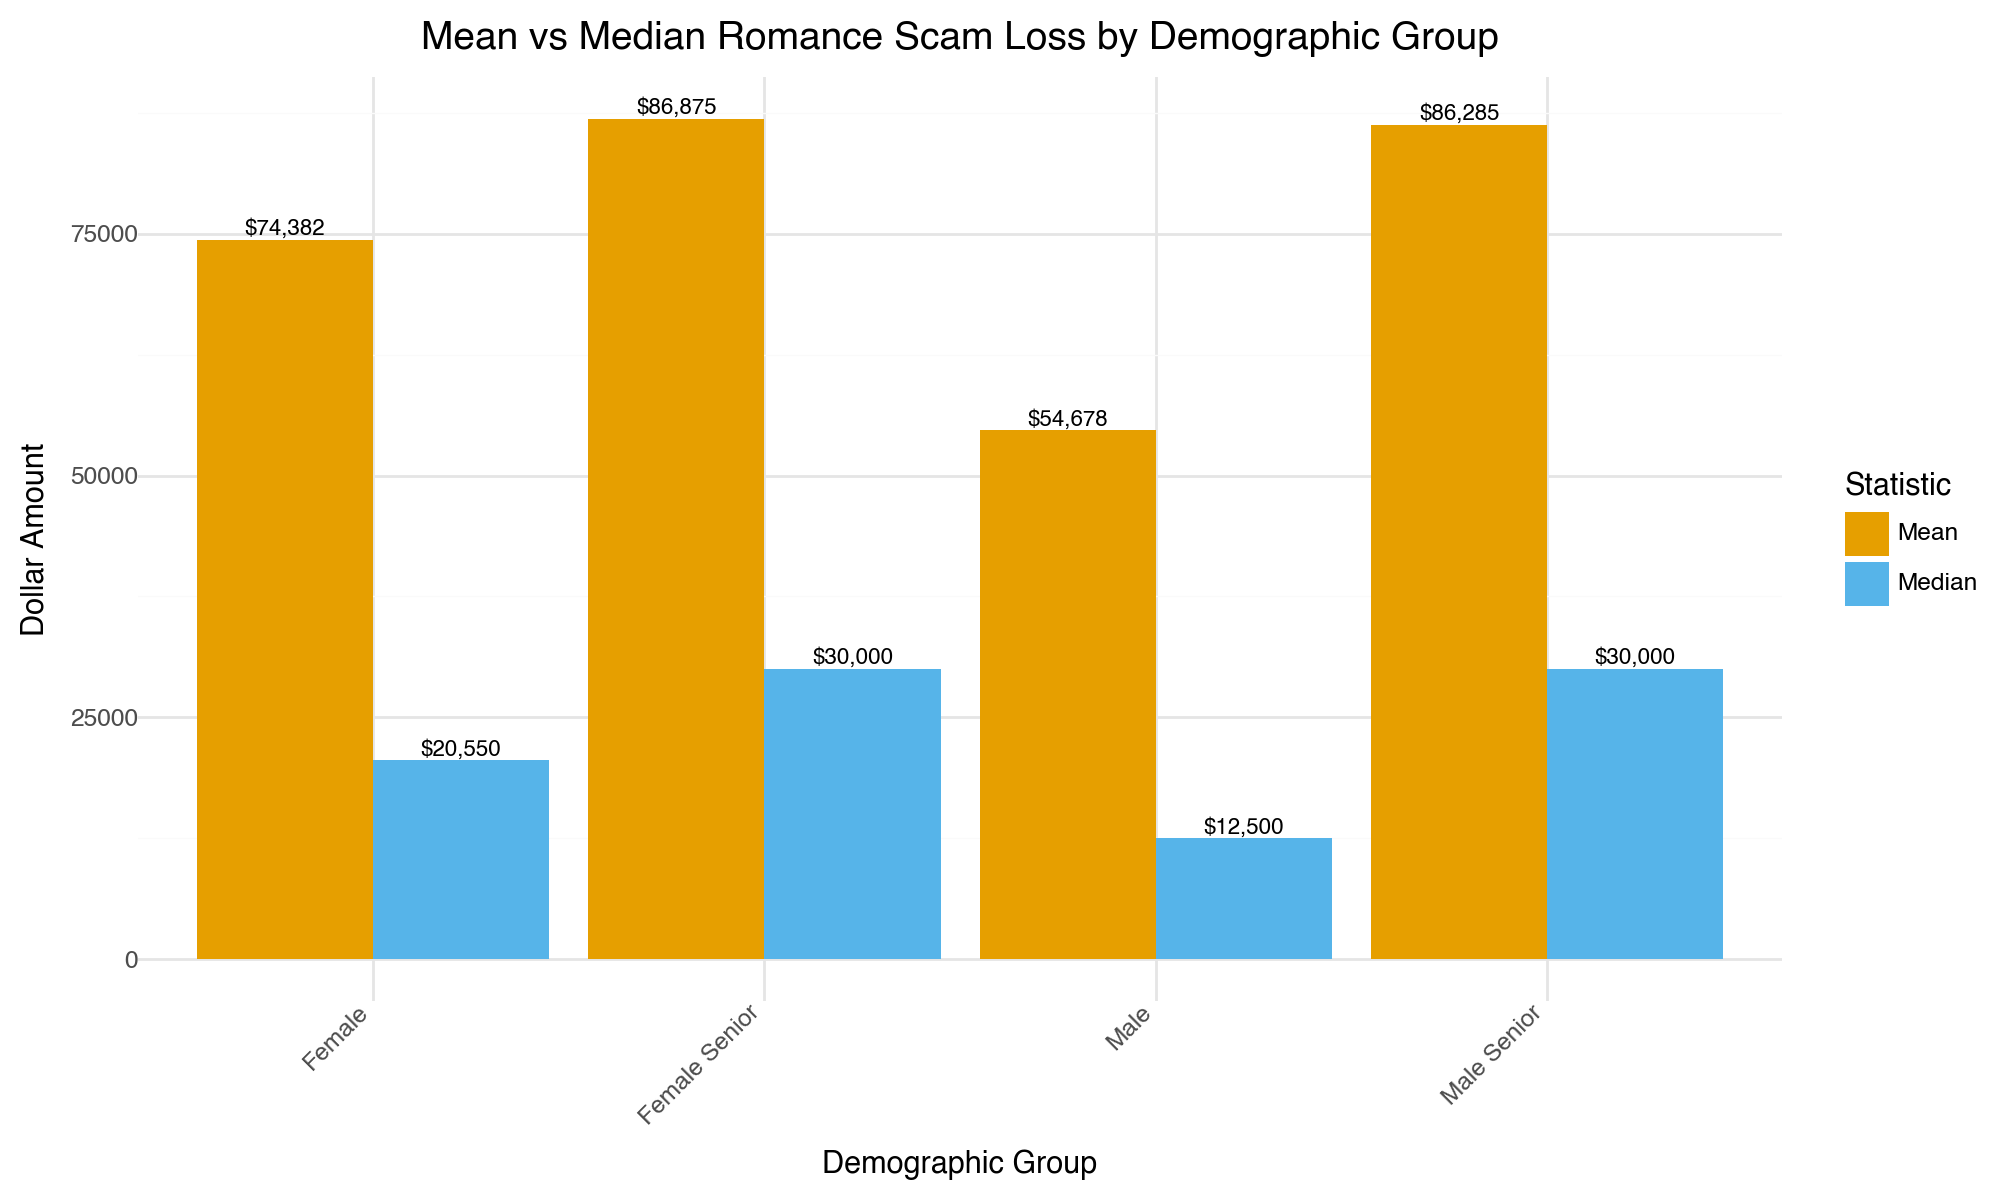

In [39]:
# Romance Scam Visualizations
import pandas as pd
import numpy as np
from plotnine import *

# Create dataframe from the statistics you pulled
romance_stats = pd.DataFrame({
    'Group': ['Female', 'Female Senior', 'Male', 'Male Senior'],
    'Count': [1514, 564, 1014, 314],
    'Mean': [74382, 86875, 54678, 86285],
    'Median': [20550, 30000, 12500, 30000],
    'Min': [1, 1, 20, 50],
    'Max': [2092997, 1611580, 2492446, 2492446],
    'StdDev': [173870, 169413, 149301, 217110],
    '25th': [5000, 9000, 2000, 4002],
    '75th': [65403, 86358, 50000, 89179]
})

# Add columns for plotting
romance_stats['Gender'] = romance_stats['Group'].apply(lambda x: 'Female' if 'Female' in x else 'Male')
romance_stats['Senior'] = romance_stats['Group'].apply(lambda x: 'Yes' if 'Senior' in x else 'No')
romance_stats['TotalLoss'] = romance_stats['Count'] * romance_stats['Median']
romance_stats['TotalLossMil'] = romance_stats['TotalLoss'] / 1000000

# 1. Mean vs Median Comparison
mean_median_df = pd.melt(romance_stats, 
                       id_vars=['Group', 'Gender', 'Senior'], 
                       value_vars=['Mean', 'Median'],
                       var_name='Statistic', value_name='Value')

(ggplot(mean_median_df, aes(x='Group', y='Value', fill='Statistic')) +
    geom_bar(stat='identity', position='dodge') +
    geom_text(aes(label='Value'), position=position_dodge(width=0.9), 
              va='bottom', format_string='${:,.0f}', size=8) +
    scale_fill_manual(values=['#E69F00', '#56B4E9']) +
    labs(title='Mean vs Median Romance Scam Loss by Demographic Group',
         x='Demographic Group',
         y='Dollar Amount') +
    theme_minimal() +
    theme(
        figure_size=(10, 6),
        plot_title=element_text(size=14, face='bold'),
        axis_text_x=element_text(angle=45, hjust=1)
    ))


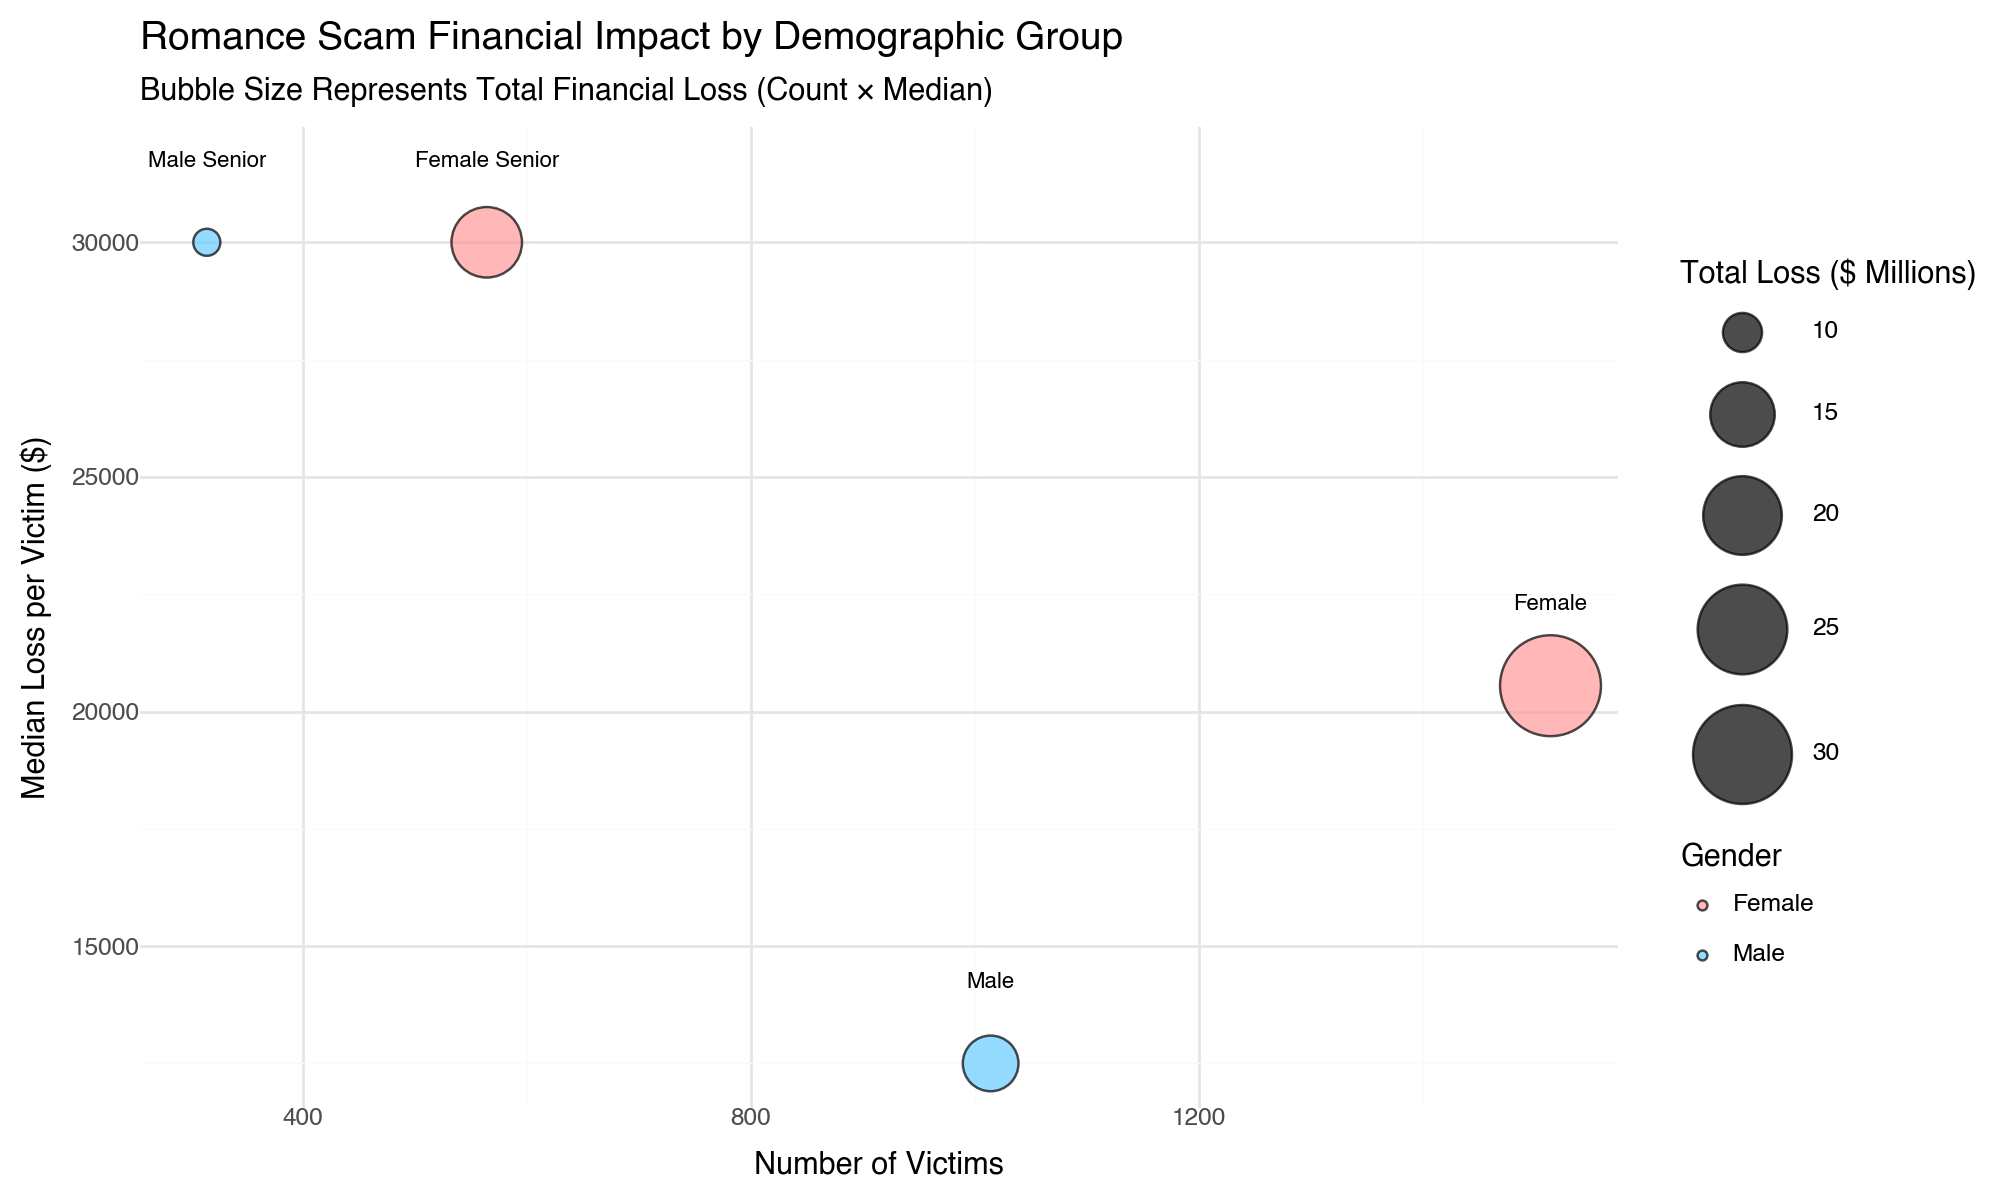

In [35]:

# 4. Total financial impact bubble chart
(ggplot(romance_stats, aes(x='Count', y='Median', size='TotalLossMil', fill='Gender')) +
    geom_point(alpha=0.7, shape='o') +
    geom_text(aes(label='Group'), nudge_y=1500, va='bottom', size=8) +
    scale_size_continuous(range=[5, 20], name='Total Loss ($ Millions)') +
    scale_fill_manual(values=['#FF9999', '#66CCFF']) +
    labs(title='Romance Scam Financial Impact by Demographic Group',
         subtitle='Bubble Size Represents Total Financial Loss (Count × Median)',
         x='Number of Victims',
         y='Median Loss per Victim ($)') +
    theme_minimal() +
    theme(
        figure_size=(10, 6),
        plot_title=element_text(size=14, face='bold')
    ))

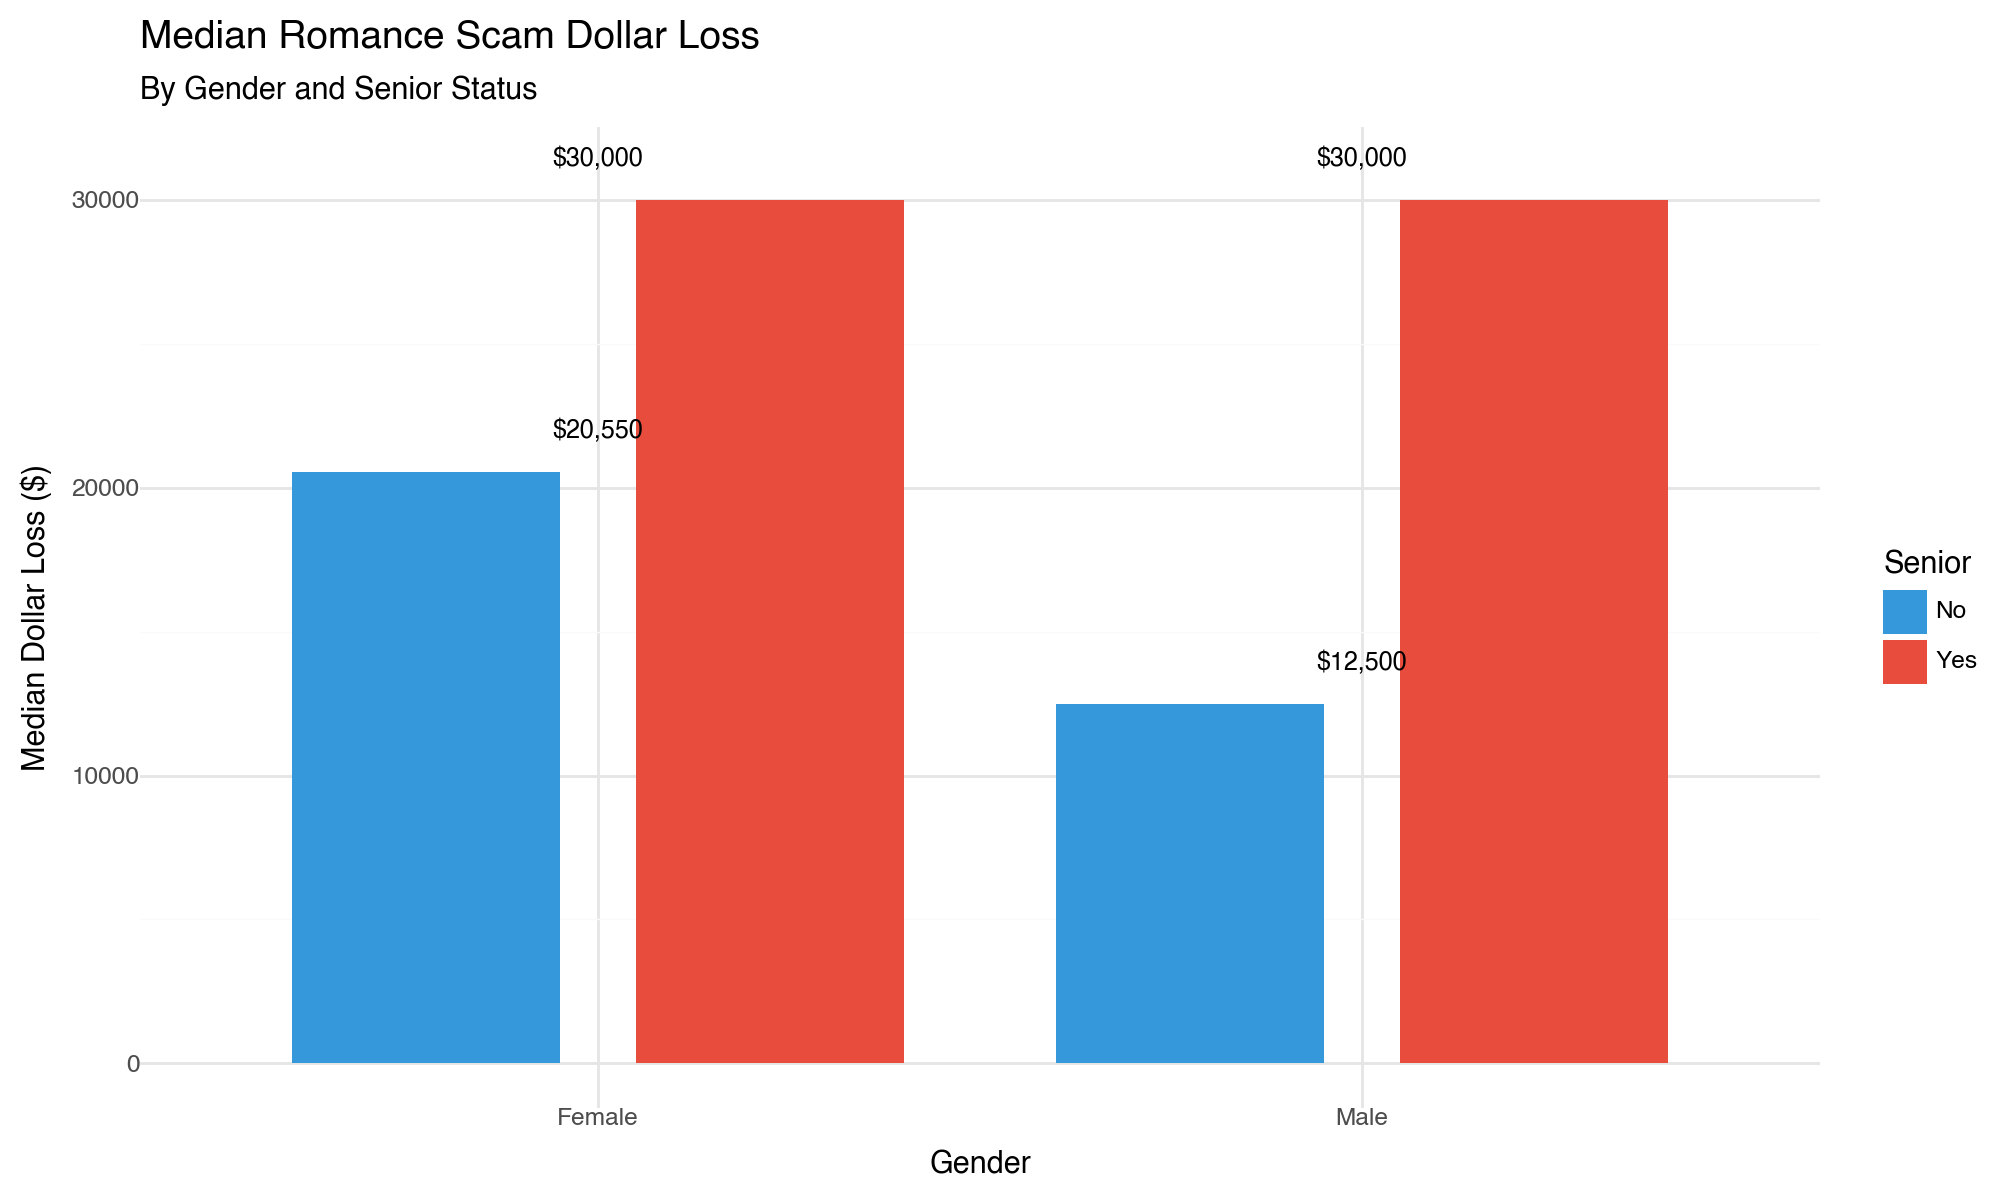

In [38]:

# 2. Median loss by gender and senior status  
(ggplot(romance_stats, aes(x='Gender', y='Median', fill='Senior')) +
    geom_bar(stat='identity', position=position_dodge(0.9), width=0.7) +
    geom_text(
        aes(label='Median'),
        position=position_dodge(0.9),
        va='bottom',
        size=9,
        format_string='${:,.0f}',
        nudge_y=1000
    ) +
    scale_fill_manual(values=['#3498db', '#e74c3c']) +
    labs(
        title='Median Romance Scam Dollar Loss',
        subtitle='By Gender and Senior Status',
        x='Gender',
        y='Median Dollar Loss ($)'
    ) +
    theme_minimal() +
    theme(
        figure_size=(10, 6),
        plot_title=element_text(size=14, face='bold')
    ))
